# 📧 Spam Detector
> **Goal:** Build a machine learning pipeline to classify SMS/email messages as **spam** or **ham (not spam)**.

**Pipeline Overview:**
1. Load the SMS Spam Collection Dataset (auto-downloaded)
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Feature Extraction (TF-IDF)
5. Train & compare models (Naive Bayes, Logistic Regression, SVM)
6. Evaluate & visualize results

## 1. Setup & Imports

In [1]:
import re
import string
import warnings
import urllib.request
import zipfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('✅ All imports successful!')

✅ All imports successful!


## 2. Load Dataset
We use the classic **SMS Spam Collection** dataset. It is downloaded automatically below.

In [2]:
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
DATA_DIR = 'data'
ZIP_PATH = os.path.join(DATA_DIR, 'smsspamcollection.zip')
FILE_PATH = os.path.join(DATA_DIR, 'SMSSpamCollection')

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(FILE_PATH):
    print('⏳ Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('✅ Download complete!')
else:
    print('✅ Dataset already present locally.')

df = pd.read_csv(FILE_PATH, sep='\t', header=None, names=['label', 'message'])
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
print(f'Dataset shape: {df.shape}')
df.head()

✅ Dataset already present locally.
Dataset shape: (5572, 3)


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('--- Class Distribution ---')
print(df['label'].value_counts())
print(f"\nSpam rate: {df['label_num'].mean()*100:.1f}%")

--- Class Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64

Spam rate: 13.4%


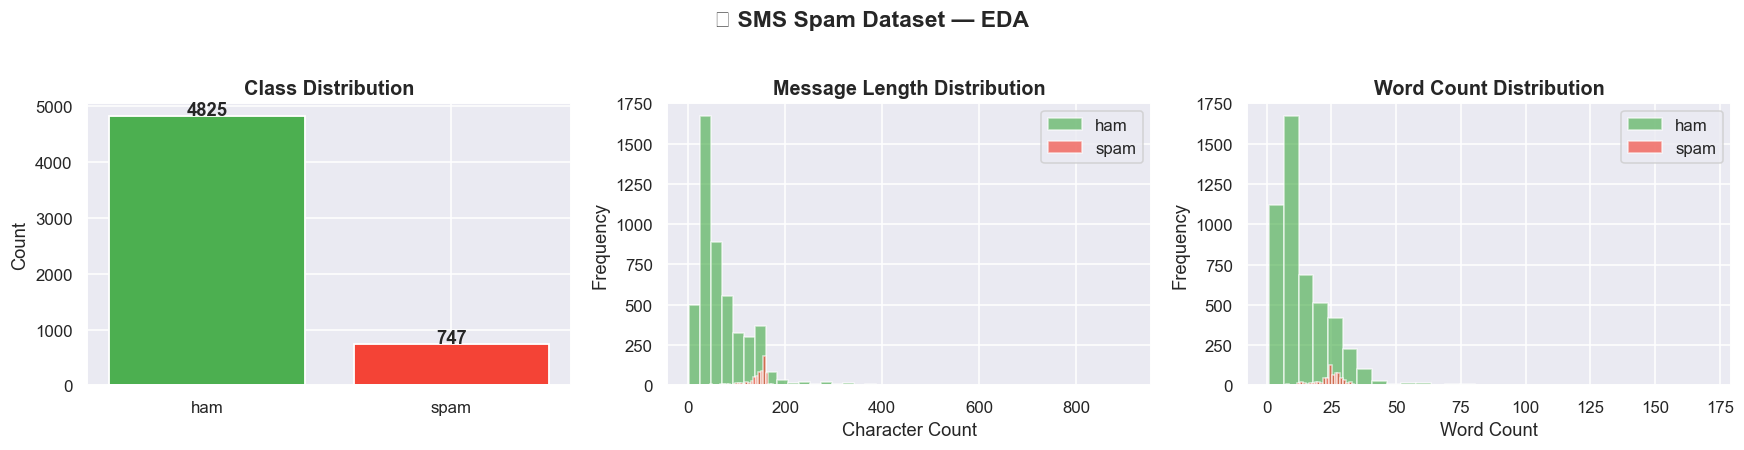

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Message length distribution
df['msg_len'] = df['message'].str.len()
for label, color in [('ham', '#4CAF50'), ('spam', '#F44336')]:
    axes[1].hist(df[df['label'] == label]['msg_len'], bins=40, alpha=0.65, label=label, color=color)
axes[1].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Word count distribution
df['word_count'] = df['message'].str.split().str.len()
for label, color in [('ham', '#4CAF50'), ('spam', '#F44336')]:
    axes[2].hist(df[df['label'] == label]['word_count'], bins=30, alpha=0.65, label=label, color=color)
axes[2].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Frequency')
axes[2].legend()

fig.suptitle('📊 SMS Spam Dataset — EDA', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
print('📝 Average stats by class:')
df.groupby('label')[['msg_len', 'word_count']].mean().round(1)

📝 Average stats by class:


,msg_len,word_count
label,,
ham,71.5,14.3
spam,138.7,23.9


## 4. Text Preprocessing

In [6]:
def preprocess_text(text: str) -> str:
    """Lowercase, remove punctuation, numbers, and extra whitespace."""
    text = text.lower()
    text = re.sub(r'\d+', ' NUM ', text)         # replace digits with token
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)  # replace URLs
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(preprocess_text)

# Preview
print('Before:', df['message'].iloc[0])
print('After: ', df['clean_message'].iloc[0])

Before: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
After:  go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


## 5. Train / Test Split

In [7]:
X = df['clean_message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'Spam rate (train): {y_train.mean()*100:.1f}%')
print(f'Spam rate (test) : {y_test.mean()*100:.1f}%')

Training samples : 4457
Testing  samples : 1115
Spam rate (train): 13.4%
Spam rate (test) : 13.4%


## 6. Build & Train Models
We compare three classic text classifiers, each wrapped in a `Pipeline` (TF-IDF → Classifier).

In [8]:
TFIDF_PARAMS = dict(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)

models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',  MultinomialNB(alpha=0.1))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',  LogisticRegression(C=5, max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',  LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
    ]),
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    # For SVM, use decision_function; for probabilistic models, use predict_proba
    if hasattr(pipeline.named_steps['clf'], 'predict_proba'):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
    results[name] = {'pipeline': pipeline, 'y_pred': y_pred, 'y_score': y_score, 'acc': acc, 'auc': auc}
    print(f'{name:25s} | Accuracy: {acc*100:.2f}%  | ROC-AUC: {auc:.4f}')

print('\n✅ All models trained!')

Naive Bayes               | Accuracy: 98.65%  | ROC-AUC: 0.9887
Logistic Regression       | Accuracy: 98.83%  | ROC-AUC: 0.9925
Linear SVM                | Accuracy: 99.01%  | ROC-AUC: 0.9925

✅ All models trained!


## 7. Detailed Evaluation

In [9]:
for name, r in results.items():
    print(f'\n═══ {name} ═══')
    print(classification_report(y_test, r['y_pred'], target_names=['Ham', 'Spam']))


═══ Naive Bayes ═══
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115


═══ Logistic Regression ═══
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.98      0.93      0.96       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115


═══ Linear SVM ═══
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.98      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weig

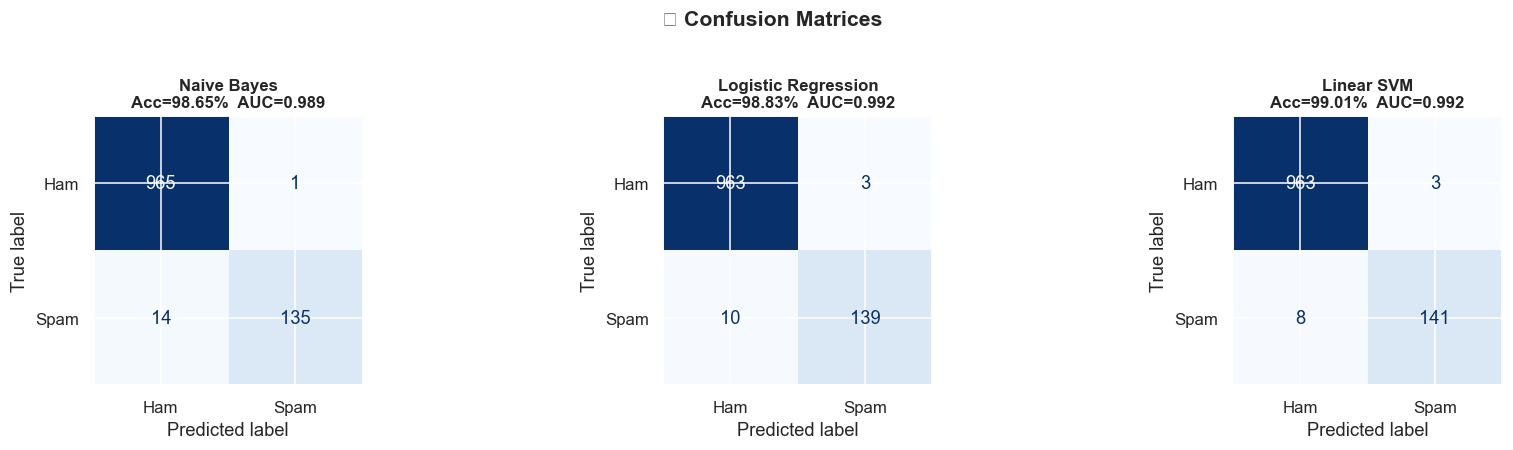

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={r["acc"]*100:.2f}%  AUC={r["auc"]:.3f}', fontsize=11, fontweight='bold')

fig.suptitle('🔵 Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

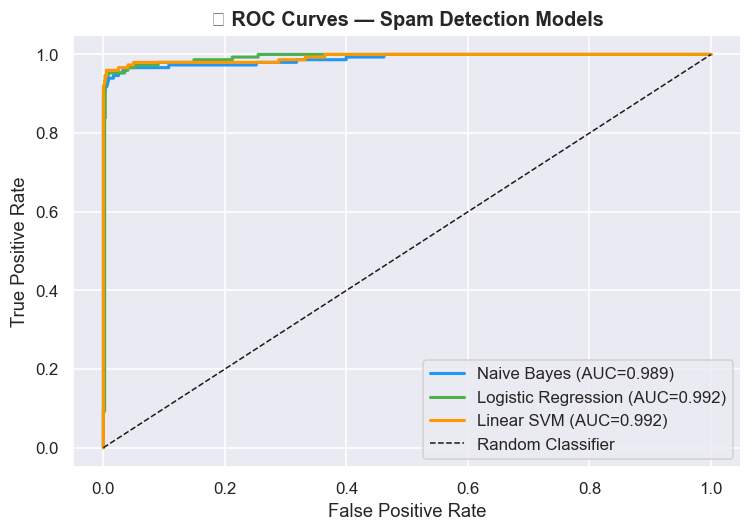

In [11]:
# ROC Curves
plt.figure(figsize=(7, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_score'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curves — Spam Detection Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Best Model — Top Spam Indicators

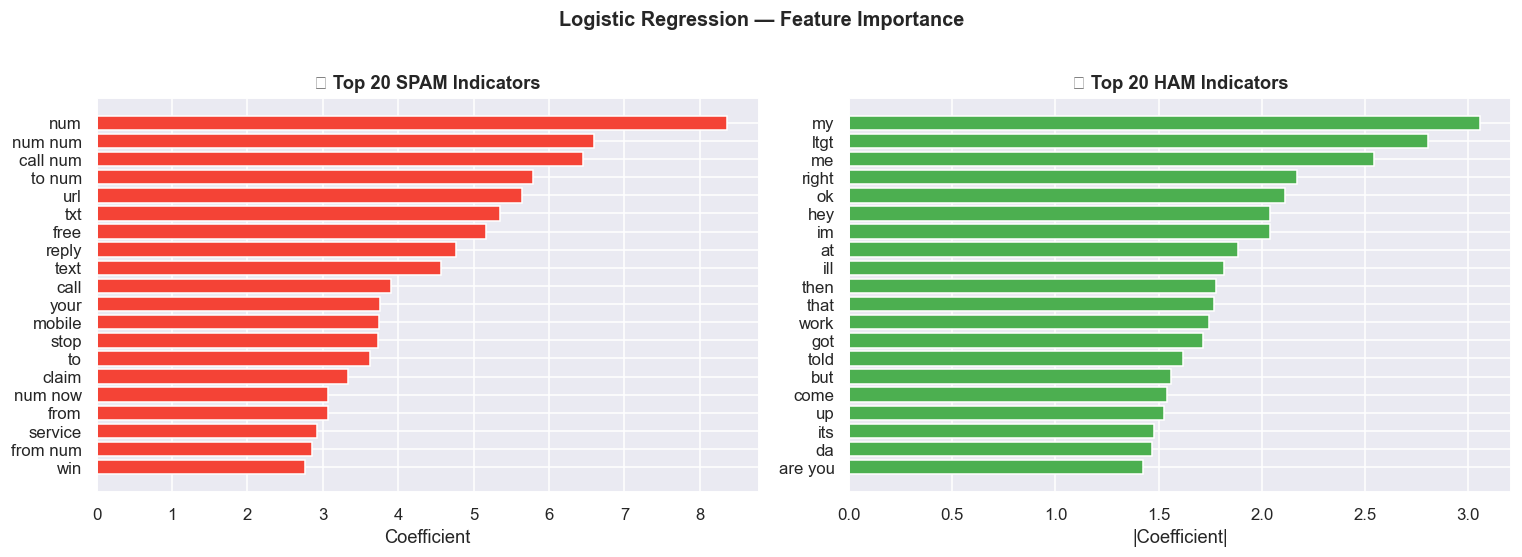

In [12]:
# Use Logistic Regression for feature importance (has interpretable coefs)
lr_pipeline = models['Logistic Regression']
feature_names = lr_pipeline.named_steps['tfidf'].get_feature_names_out()
coefs = lr_pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
top_spam = coef_df.nlargest(20, 'coef')
top_ham  = coef_df.nsmallest(20, 'coef')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_spam['feature'], top_spam['coef'], color='#F44336', edgecolor='white')
axes[0].set_title('🔴 Top 20 SPAM Indicators', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coefficient')
axes[0].invert_yaxis()

axes[1].barh(top_ham['feature'], top_ham['coef'].abs(), color='#4CAF50', edgecolor='white')
axes[1].set_title('🟢 Top 20 HAM Indicators', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Coefficient|')
axes[1].invert_yaxis()

plt.suptitle('Logistic Regression — Feature Importance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. 🔍 Predict on Custom Messages

In [13]:
best_model = models['Logistic Regression']  # swap to any model name above

test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here NOW to claim: http://win.free-gift.com",
    "Hey, are we still on for dinner tonight at 7?",
    "URGENT: Your bank account has been suspended. Call 0800-XXXXX immediately!",
    "Just finished reading the book you recommended. Really enjoyed it!",
    "Win £1000 cash prize! Text WIN to 86688. T&Cs apply. 18+.",
    "Can you pick up some groceries on the way home?",
]

clean = [preprocess_text(m) for m in test_messages]
preds = best_model.predict(clean)
probs = best_model.predict_proba(clean)[:, 1]

print(f"{'Message':60s} | {'Pred':5s} | {'Spam Prob':10s}")
print('-' * 80)
for msg, pred, prob in zip(test_messages, preds, probs):
    label = '🔴 SPAM' if pred == 1 else '🟢 HAM '
    print(f"{msg[:58]:60s} | {label} | {prob*100:6.1f}%")

Message                                                      | Pred  | Spam Prob 
--------------------------------------------------------------------------------
Congratulations! You've won a FREE iPhone. Click here NOW    | 🔴 SPAM |   89.4%
Hey, are we still on for dinner tonight at 7?                | 🟢 HAM  |    1.1%
URGENT: Your bank account has been suspended. Call 0800-XX   | 🔴 SPAM |   82.3%
Just finished reading the book you recommended. Really enj   | 🟢 HAM  |    1.4%
Win £1000 cash prize! Text WIN to 86688. T&Cs apply. 18+.    | 🔴 SPAM |   97.8%
Can you pick up some groceries on the way home?              | 🟢 HAM  |    0.4%


## 10. Cross-Validation (Robustness Check)

In [14]:
print('5-Fold Cross-Validation (F1 — Spam class):')
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1', n_jobs=-1)
    print(f'  {name:25s}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')

print('\n🎉 Notebook complete!')

5-Fold Cross-Validation (F1 — Spam class):
  Naive Bayes              : 94.61% ± 1.02%
  Logistic Regression      : 94.36% ± 0.92%
  Linear SVM               : 95.24% ± 0.70%

🎉 Notebook complete!
